<a href="https://colab.research.google.com/github/mdmehedihasan/diffusion_feb_25/blob/intro_diffusion/Synthesis_data_for_volumetric_video_streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step 1: Install Blender
# Install Blender 3.4 in Google Colab
!wget https://ftp.nluug.nl/pub/graphics/blender/release/Blender3.4/blender-3.4.0-linux-x64.tar.xz
!tar -xvf blender-3.4.0-linux-x64.tar.xz
!apt-get install libgl1-mesa-dev -y



--2025-02-07 15:36:52--  https://ftp.nluug.nl/pub/graphics/blender/release/Blender3.4/blender-3.4.0-linux-x64.tar.xz
Resolving ftp.nluug.nl (ftp.nluug.nl)... 145.220.21.40, 2001:67c:6ec:221:145:220:21:40
Connecting to ftp.nluug.nl (ftp.nluug.nl)|145.220.21.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 225689072 (215M) [application/octet-stream]
Saving to: ‘blender-3.4.0-linux-x64.tar.xz.1’

blender-3.4.0-linux 100%[===================>] 215.23M  23.2MB/s    in 9.8s    

2025-02-07 15:37:03 (22.0 MB/s) - ‘blender-3.4.0-linux-x64.tar.xz.1’ saved [225689072/225689072]

blender-3.4.0-linux-x64/
blender-3.4.0-linux-x64/license/
blender-3.4.0-linux-x64/license/THIRD-PARTY-LICENSES.txt
blender-3.4.0-linux-x64/license/jemalloc.txt
blender-3.4.0-linux-x64/license/bmonofont-i18n.ttf.txt
blender-3.4.0-linux-x64/license/BSD-3-Clause.txt
blender-3.4.0-linux-x64/license/Apache-2.0.txt
blender-3.4.0-linux-x64/license/MIT.txt
blender-3.4.0-linux-x64/license/OpenSSL.txt
b

In [ ]:
# Step 2: Install OpenCV
!pip install opencv-python-headless numpy

In [ ]:
#Step 3: Blender Script for 5-Second Video with 100 Frames
# Save the Blender rendering script
script_content = """
import bpy
import os

# Ensure output directory exists
output_dir = "/content/volumetric_video"
os.makedirs(output_dir, exist_ok=True)

# Set video output path
video_path = os.path.join(output_dir, "football_video_HR.mp4")

# Clear all objects
bpy.ops.object.select_all(action='SELECT')
bpy.ops.object.delete(use_global=False)

# Add a football (UV sphere)
bpy.ops.mesh.primitive_uv_sphere_add(radius=0.5, location=(-5, 0, 0.5))
ball = bpy.context.object

# Apply a material to the football
mat = bpy.data.materials.new(name="FootballMaterial")
mat.use_nodes = True
ball.data.materials.append(mat)

# Add a plane as the grass field
bpy.ops.mesh.primitive_plane_add(size=15, location=(0, 0, 0))
field = bpy.context.object

# Add a simple material to the field
field_mat = bpy.data.materials.new(name="GrassMaterial")
field_mat.use_nodes = True
field.data.materials.append(field_mat)

# Add a camera
bpy.ops.object.camera_add(location=(0, -10, 5))
camera = bpy.context.object
camera.rotation_euler = (1.2, 0, 0)
bpy.context.scene.camera = camera

# Add a light source
bpy.ops.object.light_add(type='SUN', location=(3, -3, 10))

# Set animation settings (5 seconds at 20 FPS = 100 frames)
bpy.context.scene.frame_start = 1
bpy.context.scene.frame_end = 100
bpy.context.scene.render.fps = 20

# Set output to high-resolution video format
bpy.context.scene.render.resolution_x = 512
bpy.context.scene.render.resolution_y = 512
bpy.context.scene.render.image_settings.file_format = 'FFMPEG'
bpy.context.scene.render.ffmpeg.format = 'MPEG4'
bpy.context.scene.render.ffmpeg.codec = 'H264'
bpy.context.scene.render.filepath = video_path

# Animate the ball rolling across the field
for i in range(1, 101):  # 100 frames
    ball.location.x = -5 + (i / 20)  # Move ball along the X-axis
    ball.rotation_euler.y += 0.2  # Simulate rolling motion
    ball.keyframe_insert(data_path="location", frame=i)
    ball.keyframe_insert(data_path="rotation_euler", frame=i)

# Render animation as a video
bpy.ops.render.render(animation=True)
"""
# Save the script to a file
with open("blender_render_script.py", "w") as f:
    f.write(script_content)


In [ ]:
#Step 4: Run Blender to Render the Video
# Run Blender in headless mode to generate the video
!blender-3.4.0-linux-x64/blender -b -P blender_render_script.py

Blender 3.4.0 (hash a95bf1ac01be built 2022-12-07 01:27:35)
GHOST/Wayland: error: XDG_RUNTIME_DIR not set in the environment.
EGL Error (0x3001): EGL_NOT_INITIALIZED: EGL is not initialized, or could not be initialized, for the specified EGL display connection.

Managed to successfully fallback to surfaceless EGL rendering!

EGL Error (0x3009): EGL_BAD_MATCH: Arguments are inconsistent (for example, a valid context requires buffers not supplied by a valid surface).
EGL Error (0x3001): EGL_NOT_INITIALIZED: EGL is not initialized, or could not be initialized, for the specified EGL display connection.

Managed to successfully fallback to surfaceless EGL rendering!

Fra:1 Mem:17.02M (Peak 18.15M) | Time:00:01.40 | Syncing Sphere
Fra:1 Mem:17.10M (Peak 18.15M) | Time:00:01.87 | Syncing Plane
Fra:1 Mem:17.10M (Peak 18.15M) | Time:00:01.87 | Syncing Camera
Fra:1 Mem:17.10M (Peak 18.15M) | Time:00:01.87 | Syncing Sun
Fra:1 Mem:17.10M (Peak 18.15M) | Time:00:01.88 | Rendering 1 / 64 samples
Fra

In [ ]:
#Step 5: Convert to Low-Resolution (LR) Video
import cv2
import os

# Paths
hr_video_path = "/content/volumetric_video/football_video_HR.mp4"
lr_video_path = "/content/volumetric_video/football_video_LR.mp4"

# Open the HR video
cap = cv2.VideoCapture(hr_video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define LR video output writer (128x128)
out = cv2.VideoWriter(lr_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (128, 128))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    # Resize frame to low resolution
    lr_frame = cv2.resize(frame, (128, 128), interpolation=cv2.INTER_AREA)
    out.write(lr_frame)

cap.release()
out.release()


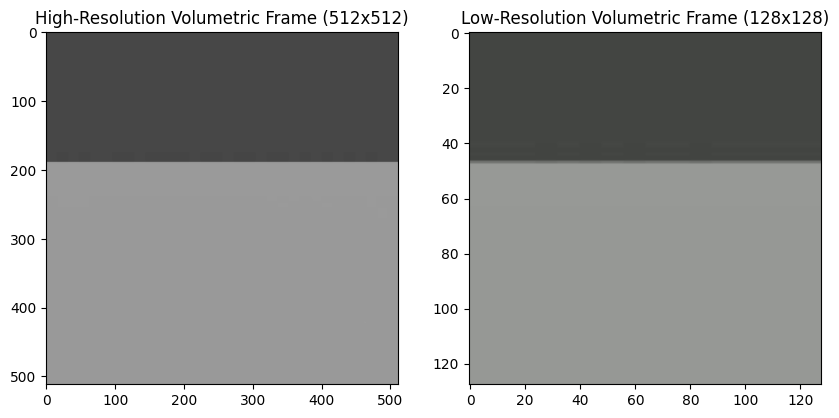

In [ ]:
#Step 6: Display Sample Frames
import matplotlib.pyplot as plt

# Load video frames
cap_hr = cv2.VideoCapture(hr_video_path)
cap_lr = cv2.VideoCapture(lr_video_path)

ret_hr, frame_hr = cap_hr.read()
ret_lr, frame_lr = cap_lr.read()

# Convert BGR to RGB for visualization
frame_hr = cv2.cvtColor(frame_hr, cv2.COLOR_BGR2RGB)
frame_lr = cv2.cvtColor(frame_lr, cv2.COLOR_BGR2RGB)

# Display frames
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("High-Resolution Volumetric Frame (512x512)")
plt.imshow(frame_hr)
plt.subplot(1, 2, 2)
plt.title("Low-Resolution Volumetric Frame (128x128)")
plt.imshow(frame_lr)
plt.show()


In [ ]:
#Step 7: Provide Download Links
from google.colab import files

# Provide download links for HR and LR videos
print("Download High-Resolution (HR) Volumetric Video:")
files.download(hr_video_path)

print("Download Low-Resolution (LR) Volumetric Video:")
files.download(lr_video_path)


Download High-Resolution (HR) Volumetric Video:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download Low-Resolution (LR) Volumetric Video:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>